=== DATASET ORIGINAL ===
             age       salaire  experience
count   7.000000      7.000000    7.000000
mean   31.857143  68571.428571    7.142857
std     7.988086  18192.096662    6.491753
min    22.000000  45000.000000    1.000000
25%    26.500000  55000.000000    3.000000
50%    30.000000  70000.000000    5.000000
75%    36.500000  80000.000000    9.000000
max    45.000000  95000.000000   20.000000

=== APRÈS STANDARDSCALER (μ=0, σ=1) ===
        age  salaire  experience
count  7.00     7.00        7.00
mean  -0.00     0.00       -0.00
std    1.08     1.08        1.08
min   -1.33    -1.40       -1.02
25%   -0.72    -0.81       -0.69
50%   -0.25     0.08       -0.36
75%    0.63     0.68        0.31
max    1.78     1.57        2.14

=== APRÈS MINMAXSCALER ([0,1]) ===
        age  salaire  experience
count  7.00     7.00        7.00
mean   0.43     0.47        0.32
std    0.35     0.36        0.34
min    0.00     0.00        0.00
25%    0.20     0.20        0.11
50%    0.35     

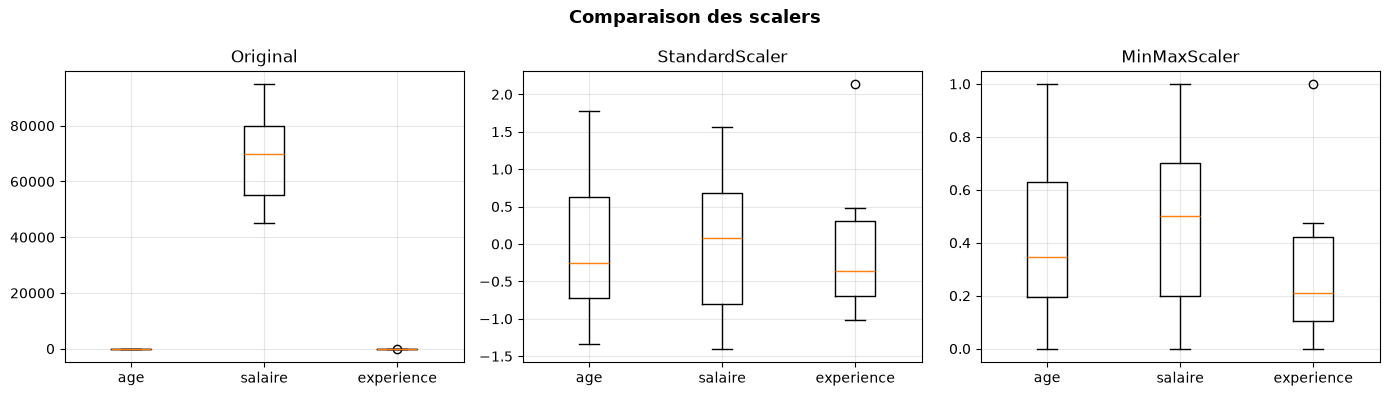

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Dataset avec des échelles très différentes
df = pd.DataFrame({
    "age":       [25, 30, 35, 28, 22, 45, 38],
    "salaire":   [50000, 70000, 85000, 60000, 45000, 95000, 75000],
    "experience":[2, 5, 10, 4, 1, 20, 8]
})

print("=== DATASET ORIGINAL ===")
print(df.describe())

# 1. StandardScaler : (x - mean) / std → μ=0, σ=1
scaler_std = StandardScaler()
df_std = pd.DataFrame(
    scaler_std.fit_transform(df),
    columns=df.columns
)

# 2. MinMaxScaler : (x - min) / (max - min) → [0, 1]
scaler_mm = MinMaxScaler()
df_mm = pd.DataFrame(
    scaler_mm.fit_transform(df),
    columns=df.columns
)

# 3. RobustScaler : utilise médiane et IQR → robuste aux outliers
scaler_rob = RobustScaler()
df_rob = pd.DataFrame(
    scaler_rob.fit_transform(df),
    columns=df.columns
)

print("\n=== APRÈS STANDARDSCALER (μ=0, σ=1) ===")
print(df_std.describe().round(2))

print("\n=== APRÈS MINMAXSCALER ([0,1]) ===")
print(df_mm.describe().round(2))

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, data, titre in zip(axes,
    [df, df_std, df_mm],
    ["Original", "StandardScaler", "MinMaxScaler"]):
    ax.boxplot([data[col] for col in data.columns],
               tick_labels=data.columns)
    ax.set_title(titre)
    ax.grid(True, alpha=0.3)

plt.suptitle("Comparaison des scalers", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [3]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

df = pd.DataFrame({
    "nom": ["Alice", "Bob", "Charlie", "David", "Emma"],
    "ville": ["Paris", "Lyon", "Paris", "Bordeaux", "Lyon"],
    "niveau": ["Junior", "Senior", "Senior", "Junior", "Junior"]
})

print("=== DATASET ORIGINAL ===")
print(df)

# 1. Label Encoding — convertit en nombres 0, 1, 2...
# Attention : implique un ordre (Lyon=0, Paris=2 → Paris "vaut plus" que Lyon ?)
# Utiliser seulement pour les variables ORDINALES (Junior < Senior)
le = LabelEncoder()
df["niveau_encoded"] = le.fit_transform(df["niveau"])
print("\n=== LABEL ENCODING (niveau) ===")
print(df[["niveau", "niveau_encoded"]])
print(f"Classes : {le.classes_}")

# 2. One-Hot Encoding — crée une colonne binaire par catégorie
# Utiliser pour les variables NOMINALES (pas d'ordre : Paris, Lyon, Bordeaux)
df_ohe = pd.get_dummies(df, columns=["ville"], prefix="ville")
print("\n=== ONE-HOT ENCODING (ville) ===")
print(df_ohe)

# Pourquoi One-Hot ? 
# Si on encode Paris=2, Lyon=1, Bordeaux=0
# Le modèle pense que Paris > Lyon > Bordeaux
# Ce qui est faux ! Aucune ville ne "vaut plus" qu'une autre
print("\n=== RÉSUMÉ ===")
print("Label Encoding → variables ordinales (ordre naturel : Junior < Senior)")
print("One-Hot Encoding → variables nominales (pas d'ordre : villes, couleurs...)")

=== DATASET ORIGINAL ===
       nom     ville  niveau
0    Alice     Paris  Junior
1      Bob      Lyon  Senior
2  Charlie     Paris  Senior
3    David  Bordeaux  Junior
4     Emma      Lyon  Junior

=== LABEL ENCODING (niveau) ===
   niveau  niveau_encoded
0  Junior               0
1  Senior               1
2  Senior               1
3  Junior               0
4  Junior               0
Classes : ['Junior' 'Senior']

=== ONE-HOT ENCODING (ville) ===
       nom  niveau  niveau_encoded  ville_Bordeaux  ville_Lyon  ville_Paris
0    Alice  Junior               0           False       False         True
1      Bob  Senior               1           False        True        False
2  Charlie  Senior               1           False       False         True
3    David  Junior               0            True       False        False
4     Emma  Junior               0           False        True        False

=== RÉSUMÉ ===
Label Encoding → variables ordinales (ordre naturel : Junior < Senior)
One-H

=== MÉTHODE IQR ===
Q1=43.99, Q3=55.21, IQR=11.21
Borne inférieure : 27.17
Borne supérieure : 72.03
Outliers détectés : 5
         valeur
74    23.802549
100  150.000000
101  160.000000
102  -30.000000
103  200.000000

=== MÉTHODE Z-SCORE ===
Outliers (|z| > 3) : 4


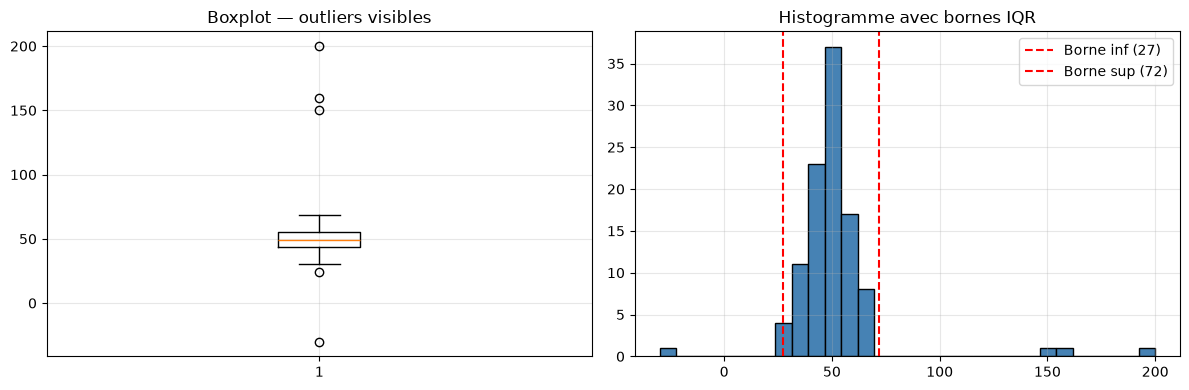

In [5]:
# DÉTECTION DES OUTLIERS

np.random.seed(42)
data = np.concatenate([
    np.random.normal(50, 10, 100),  # données normales
    [150, 160, -30, 200]            # outliers évidents
])

df_out = pd.DataFrame({"valeur": data})

print("=== MÉTHODE IQR ===")
Q1 = df_out["valeur"].quantile(0.25)
Q3 = df_out["valeur"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_out[(df_out["valeur"] < lower) | (df_out["valeur"] > upper)]
print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Borne inférieure : {lower:.2f}")
print(f"Borne supérieure : {upper:.2f}")
print(f"Outliers détectés : {len(outliers)}")
print(outliers)

print("\n=== MÉTHODE Z-SCORE ===")
from scipy import stats
z_scores = np.abs(stats.zscore(df_out["valeur"]))
outliers_z = df_out[z_scores > 3]
print(f"Outliers (|z| > 3) : {len(outliers_z)}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df_out["valeur"])
axes[0].set_title("Boxplot — outliers visibles")
axes[0].grid(True, alpha=0.3)

axes[1].hist(df_out["valeur"], bins=30, 
             color="steelblue", edgecolor="black")
axes[1].axvline(lower, color="red", linestyle="--", label=f"Borne inf ({lower:.0f})")
axes[1].axvline(upper, color="red", linestyle="--", label=f"Borne sup ({upper:.0f})")
axes[1].set_title("Histogramme avec bornes IQR")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()